The papers studied have the intention to increase vorticity and with that have higher details in the simulation. 
The paper about vorticity refinement shows more details in some images and also adds an analisys claiming they increase the kinectic energy of the system with their approach, what would align with the fact that they add velocity to the system. They also want to show that their algorithm does not add energy indefinetely (like MP), it just adds in the moments where the fluid is moving more, what would be the moment where the most details are lost.

The vorticity confinement paper just shows increase in details but not in energy.

I spent much time trying to check if my implementation was correct by checking if indeed the energy increased or if the enstropgy in the system increases, but that's not the case for 3D VR implementation. And also not happens for VC implementation.

- What happens in inviscid liquids? Because in this case we wouldn't have an issue with the laplacian in theory
- Is this related to being small simulations? Would it make sense in a larger scenario, because the divergent part would be larger than the dissipation.
- Are we seeing a visual difference?

- Does this have to do with the fact that they are "ëxplict" integration? (should use the advected velocity?should compute derivative in the beginning of loop?)
- Should we consider the forces term into account? (should change the derivative equation?)
- Is there something to do with SPH formulation? 

In [17]:
import meshio
import os
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import pandas as pd
from numpy import genfromtxt


In [3]:
splishsplash_path = 'C:/Users/gabri/Documents/thesis/SPlisHSPlasH/'
scenes_path = splishsplash_path + 'data/Scenes/'
output_path = splishsplash_path + 'output'
scene = 'DamBreakModel'

In [4]:
folders = os.listdir(output_path + '/' + scene)
folders.remove('log')
print(folders)

['inviscid', 'visc_standard_005', 'vtk']


## Basic examples with VR, VC, MP with viscosity (paper only has viscosity)

#### Plots for kin energy and total energy
#### Plots for enstrophy
#### Plots for the VR equation (showing dissipation, and how the derivative decreases the vorticity)
#### video with all dam breaks side by side

In [66]:
folder_path = output_path + '/' + scene + '/visc_standard_005/'
print(folder_path)

folders = os.listdir(folder_path)
folders.remove('vtk_vr10_derneg_notgood')
folders.remove('vc_05_crossneg')
folders.remove('vr_10_crossneg')
folders.remove('vr_10_deltav_neg')
print(folders)

C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/DamBreakModel/visc_standard_005/
['mp_01', 'mp_04', 'vc_01', 'vc_05', 'vr_10', 'vr_13', 'vr_baseline']


#### Energy

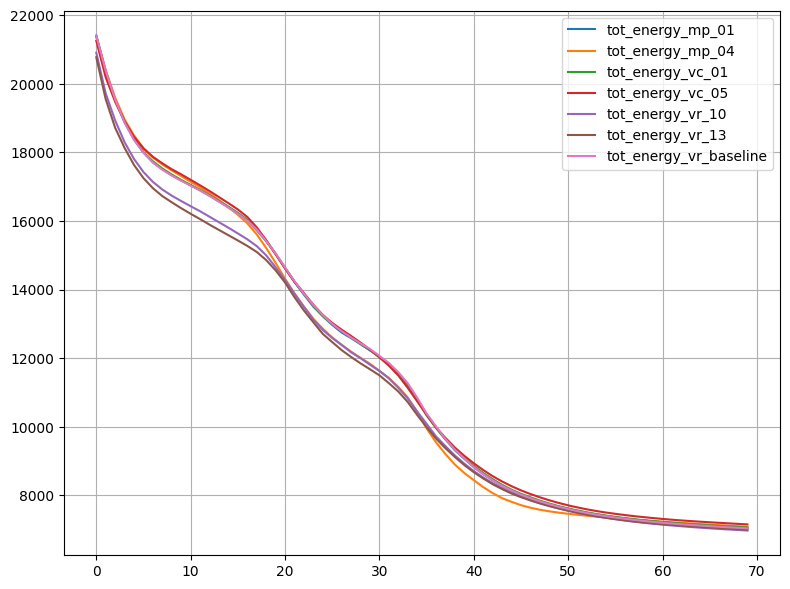

In [67]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['mass']

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

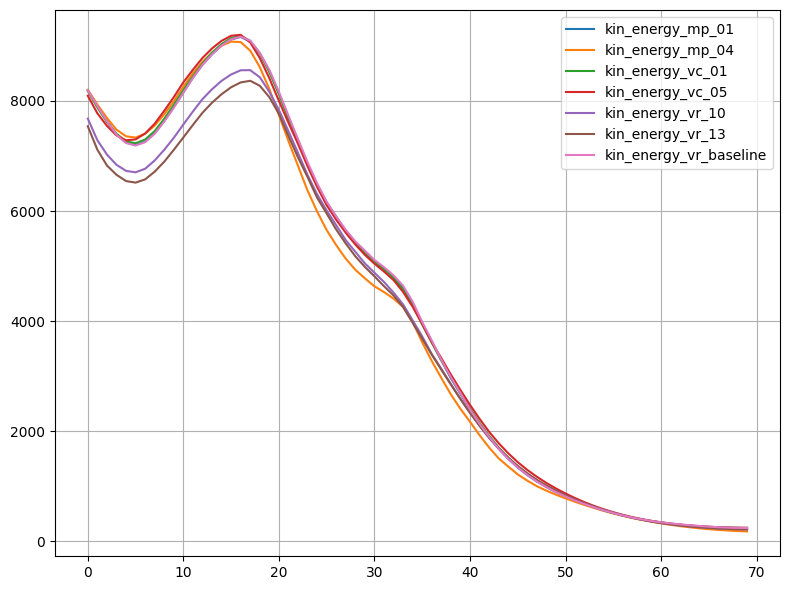

In [68]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['mass']

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(kin_energy, label="kin_energy_{}".format(folder))
#     plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### Enstrophy

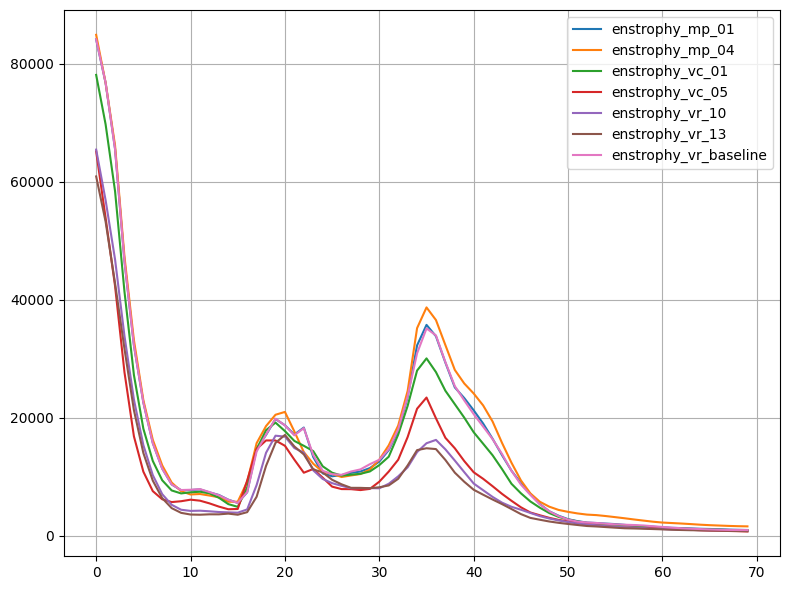

In [69]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['mass']

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((mass * norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    plt.plot(enstrophy, label="enstrophy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### VR equation - vortcity dissipation

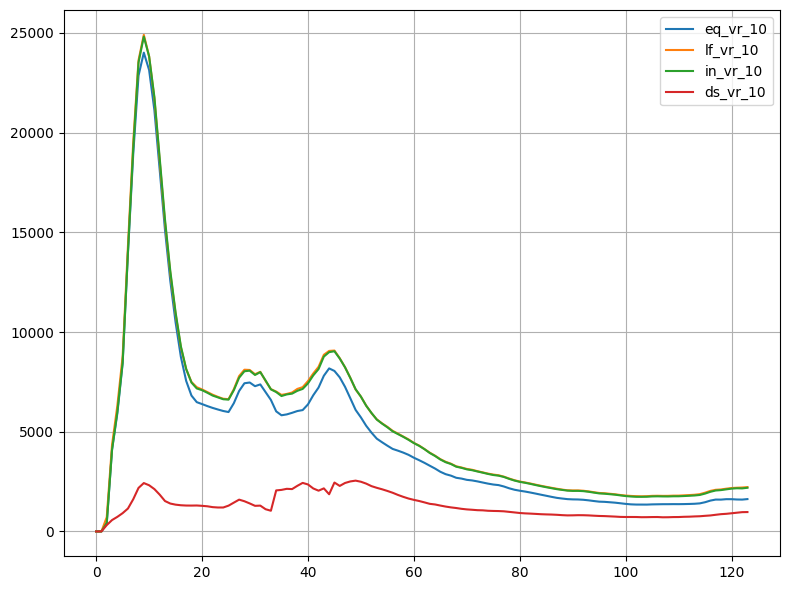

In [73]:
plt.figure(figsize=(8, 6))

for folder in ['vr_10']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)

    listens_eq = []
    listens_lf = []
    listens_in = []
    listens_ds = []
    listens_der = []
    listens_la = []
    listens_gr = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        vorticityeq = mesh.point_data['m_vorticity_equation']
        vorticitylf = mesh.point_data['vorticity_linear_field']
        vorticityinit = mesh.point_data['m_vorticity_init']
        vorticityds = mesh.point_data['vorticity_dissipation']
        vorticityla = mesh.point_data['m_vorticity_rate_laplacian']
        vorticitygr = mesh.point_data['m_vorticity_rate_gradient']
        vorticityder = mesh.point_data['vorticity_derivative']
                
        number_particles = len(h)
        if number_particles > 0:                                
            ens_eq = np.sum((norm(vorticityeq, axis=1)))
            listens_eq.append(ens_eq)
            ens_lf = np.sum((norm(vorticitylf, axis=1)))
            listens_lf.append(ens_lf)
            ens_in = np.sum((norm(vorticityinit, axis=1)))
            listens_in.append(ens_in)
            ens_ds = np.sum((norm(vorticityds, axis=1)))
            listens_ds.append(ens_ds)

#             ens_la = np.sum((norm(vorticityla, axis=1)))
#             listens_la.append(ens_la)
#             ens_gr = np.sum((norm(vorticitygr, axis=1)))
#             listens_gr.append(ens_gr)

    plt.plot(listens_eq, label="eq_{}".format(folder))
    plt.plot(listens_lf, label="lf_{}".format(folder))
    plt.plot(listens_in, label="in_{}".format(folder))
    plt.plot(listens_ds, label="ds_{}".format(folder))

#     plt.plot(listens_la, label="la_{}".format(folder))
#     plt.plot(listens_gr, label="gr_{}".format(folder))
# 
plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

## What happens in inviscid fluids?

#### No viscosity to study the derivative
#### Plots for the derivative in VR
#### Plots for enstrophy
#### Plots for kin energy
#### Video

In [77]:
folder_path = output_path + '/' + scene + '/inviscid/'
# all visc in this folder is 0 and no xsph is applied
print(folder_path)

folders = os.listdir(folder_path)
print(folders)

C:/Users/gabri/Documents/thesis/SPlisHSPlasH/output/DamBreakModel/inviscid/
['mp_04', 'vc_05', 'vr_10', 'vr_13', 'vr_baseline']


#### Energy

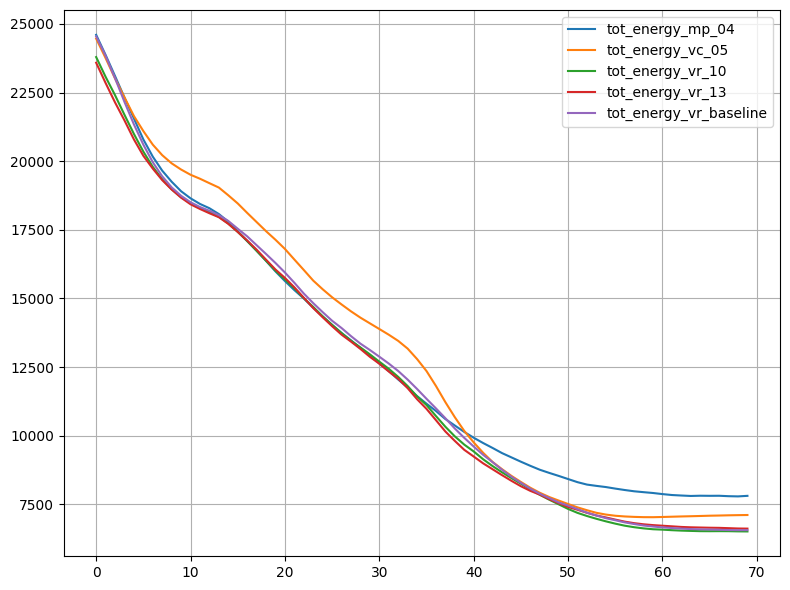

In [79]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['mass']

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
#     plt.plot(kin_energy, label="kin_energy_{}".format(folder))
    plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

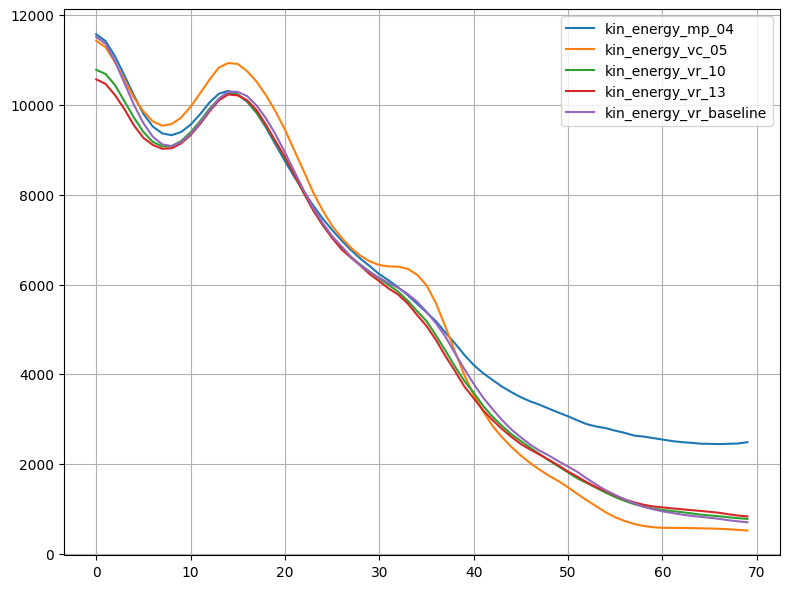

In [80]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    kin_energy = []
    pot_energy = []
    total_energy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        h = mesh.points[:,1]
        velocity = mesh.point_data['velocity']
        mass = mesh.point_data['mass']

        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(mass * h * 9.81)
            pot_energy.append(aux_pot_energy)
            
            aux_kin_energy = np.sum((mass * norm(velocity, axis=1)**2) / 2)
            kin_energy.append(aux_kin_energy)

            total_energy.append((aux_pot_energy + aux_kin_energy))
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(kin_energy, label="kin_energy_{}".format(folder))
#     plt.plot(total_energy, label="tot_energy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### Enstrophy

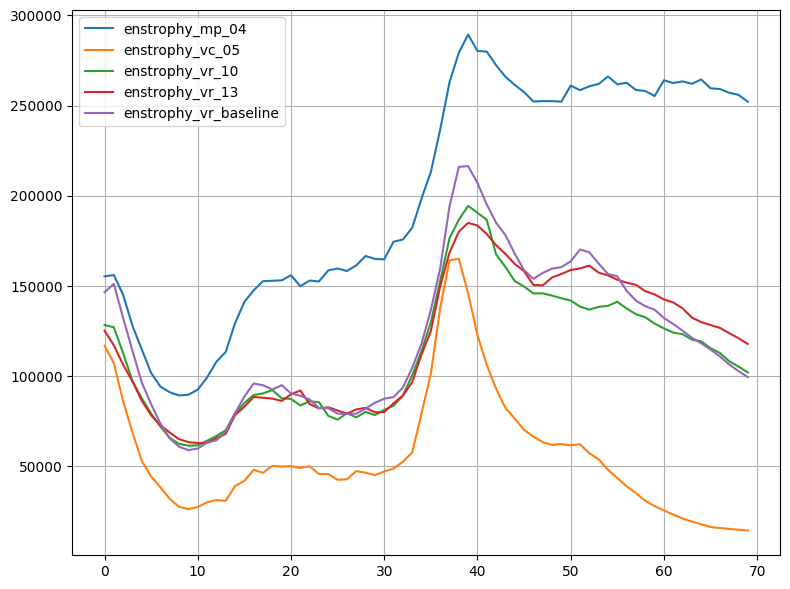

In [81]:
plt.figure(figsize=(8, 6))

for folder in folders:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)
    
    enstrophy = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        mass = mesh.point_data['mass']

        number_particles = len(h)
        if number_particles > 0:           
            aux_kin_ens = np.sum((mass * norm(vorticity, axis=1)**2) / 2)
            enstrophy.append(aux_kin_ens)
        else:
            enstrophy.append(0)

    plt.plot(enstrophy, label="enstrophy_{}".format(folder))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

#### VR equation - vortcity dissipation

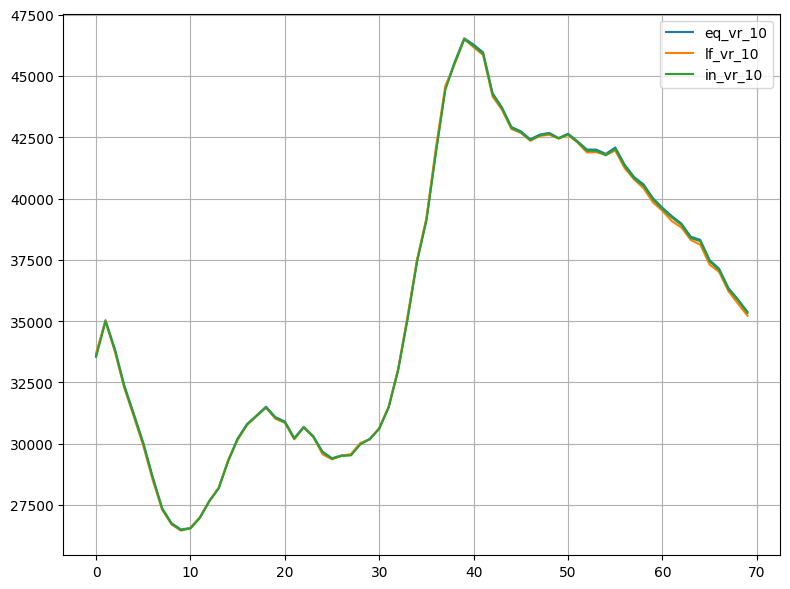

In [85]:
plt.figure(figsize=(8, 6))

for folder in ['vr_10']:
    full_path = folder_path + folder + '/'
    files = os.listdir(full_path)

    listens_eq = []
    listens_lf = []
    listens_in = []
    listens_ds = []
    listens_der = []
    listens_la = []
    listens_gr = []
    
    for i in range(10,80):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points

        vorticity = mesh.point_data['vorticity_corrected_end']
        vorticityeq = mesh.point_data['m_vorticity_equation']
        vorticitylf = mesh.point_data['vorticity_linear_field']
        vorticityinit = mesh.point_data['m_vorticity_init']
        vorticityds = mesh.point_data['vorticity_dissipation']
        vorticityla = mesh.point_data['m_vorticity_rate_laplacian']
        vorticitygr = mesh.point_data['m_vorticity_rate_gradient']
        vorticityder = mesh.point_data['vorticity_derivative']
                
        number_particles = len(h)
        if number_particles > 0:                                
            ens_eq = np.sum((norm(vorticityeq, axis=1)))
            listens_eq.append(ens_eq)
            ens_lf = np.sum((norm(vorticitylf, axis=1)))
            listens_lf.append(ens_lf)
            ens_in = np.sum((norm(vorticityinit, axis=1)))
            listens_in.append(ens_in)
            ens_ds = np.sum((norm(vorticityds, axis=1)))
            listens_ds.append(ens_ds)

#             ens_la = np.sum((norm(vorticityla, axis=1)))
#             listens_la.append(ens_la)
#             ens_gr = np.sum((norm(vorticitygr, axis=1)))
#             listens_gr.append(ens_gr)

    plt.plot(listens_eq, label="eq_{}".format(folder))
    plt.plot(listens_lf, label="lf_{}".format(folder))
    plt.plot(listens_in, label="in_{}".format(folder))
#     plt.plot(listens_ds, label="ds_{}".format(folder))

#     plt.plot(listens_la, label="la_{}".format(folder))
#     plt.plot(listens_gr, label="gr_{}".format(folder))
# 
plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

## Some large simulations
Is the viscosity difusion more impactful in small scenes? Is there specific scenarios where energy increases or vorticity increases? Maybe only increases on part of the system

### Big dam break with wall (only gravity force, how does it react)
There are 2 scenarios simulated on the cluster, need to take csvs from there for plots here. Working on generating photos of the differences

In [23]:
thesis_path = 'C:/Users/gabri/Documents/thesis'
print(thesis_path)

files = os.listdir(thesis_path + '/dambreaklargewithwall/')
files.remove('baselinee')
files.remove('vr13')
files.remove('enstrophy_DamBreakModelLargeWithWall.csv')
files.remove('enstrophy_DamBreakModelLargeWithWallBaseline.csv')

print(files)

C:/Users/gabri/Documents/thesis
['kin_energy_DamBreakModelLargeWithWall.csv', 'kin_energy_DamBreakModelLargeWithWallBaseline.csv', 'pot_energy_DamBreakModelLargeWithWall.csv', 'pot_energy_DamBreakModelLargeWithWallBaseline.csv', 'total_energy_DamBreakModelLargeWithWall.csv', 'total_energy_DamBreakModelLargeWithWallBaseline.csv']


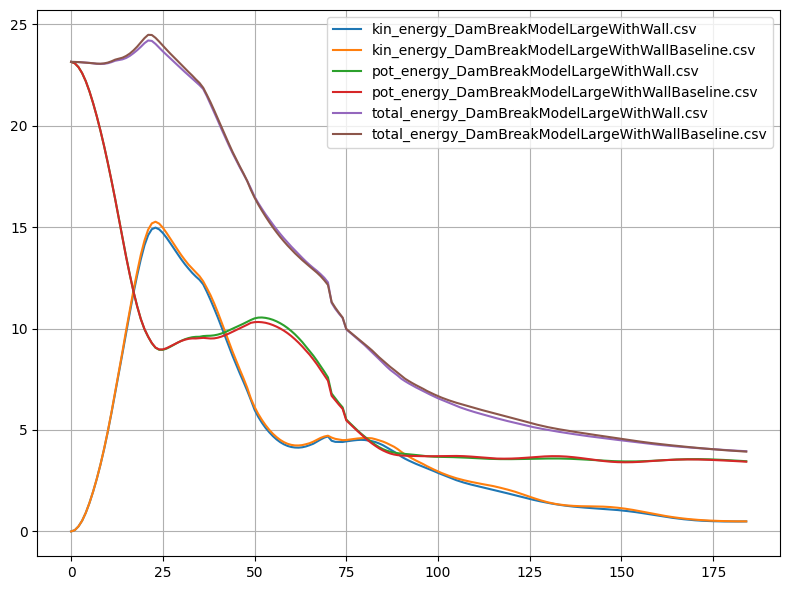

In [24]:
# Energy
plt.figure(figsize=(8, 6))
for file in files:
#     print(file)
    my_array = genfromtxt(thesis_path + '/dambreaklargewithwall/' + file, delimiter=',')

    plt.plot(my_array, label="{}".format(file))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

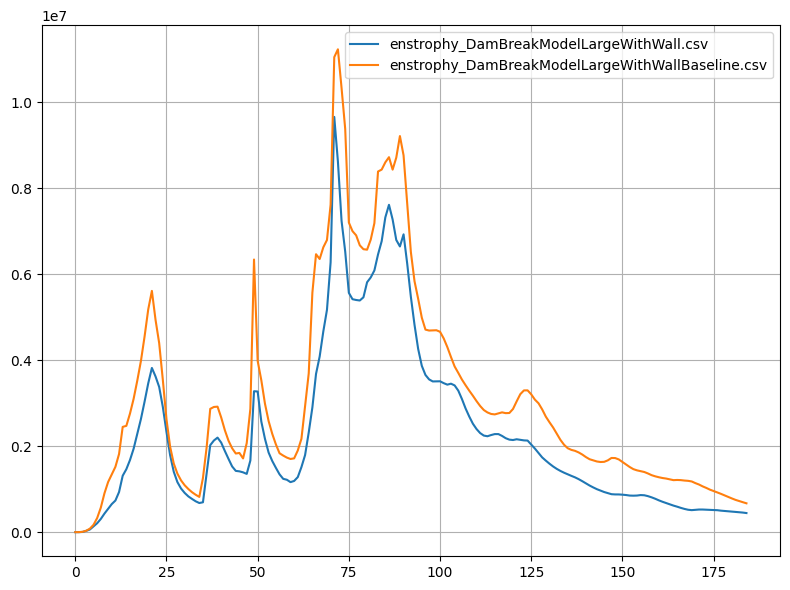

In [25]:
# Enstrophy
plt.figure(figsize=(8, 6))
for file in ['enstrophy_DamBreakModelLargeWithWall.csv', 'enstrophy_DamBreakModelLargeWithWallBaseline.csv']:
#     print(file)
    my_array = genfromtxt(thesis_path + '/dambreaklargewithwall/' + file, delimiter=',')

    plt.plot(my_array, label="{}".format(file))

plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()

### Motor Large (energy being added to the system by motor, how does it react)

### Rankine in 3d?

## Is there a change in looks?
https://www.youtube.com/watch?v=juCXCzmgcqE

###### Heatmap of velocity vorticity accross different scenarios could show if some method gives more impact in specific parts of the simulation (on a part where energy is added for example)

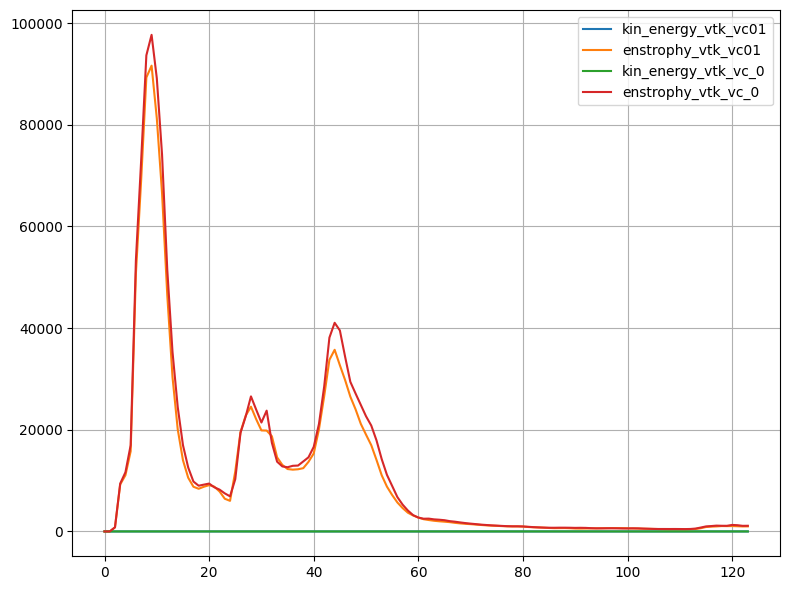

In [13]:
plt.figure(figsize=(8, 6))

for folder in ['vtk_vc01', 'vtk_vc_0']:
    full_path = output_path + '/' + scene + '/' + folder + '/'
    files = os.listdir(full_path)

    enstrophy = []
    kin_energy = []
    kin_energy_before = []
    kin_energy_after=[]
    pot_energy = []
    total_energy = []
    listens_eq = []
    listens_lf = []
    listens_in = []
    listens_ds = []
    listens_der = []
    listens_la = []
    listens_gr = []
    diss_aqui = []
    ens_vc = []
    
    for i in range(1,125):
        file = 'ParticleData_Fluid_{}.vtk'.format(i)

        mesh = meshio.read(full_path + file)
        positions = mesh.points
#         print(mesh.point_data)

        h = mesh.points[:,1]
        velocity_before = mesh.point_data['m_velocity_from_dfsph']
        velocity_after = mesh.point_data['m_velocity_corrected_end']
        velocity = mesh.point_data['velocity']
        vorticity = mesh.point_data['vorticity_corrected_end']
        vorticityeq = mesh.point_data['m_vorticity_equation']
        vorticitylf = mesh.point_data['vorticity_linear_field']
        vorticityinit = mesh.point_data['m_vorticity_init']
        vorticityds = mesh.point_data['vorticity_dissipation']
        vorticityla = mesh.point_data['m_vorticity_rate_laplacian']
        vorticitygr = mesh.point_data['m_vorticity_rate_gradient']
        vorticityder = mesh.point_data['vorticity_derivative']
        
        vorticity_vc = mesh.point_data['angular_velocity']
        
        number_particles = len(h)
        if number_particles > 0:
            aux_pot_energy = np.sum(h * 9.81)
            pot_energy.append(aux_pot_energy)
            aux_kin_energy = np.sum(norm(velocity, axis=1))
            kin_energy.append(aux_kin_energy/number_particles)
            
            aux_ens_vc = np.sum((norm(vorticity_vc, axis=1)**2) /2)
            ens_vc.append(aux_ens_vc)
            
#             aux_kin_energy_before = np.sum(norm(velocity_before, axis=1))
#             kin_energy_before.append(aux_kin_energy_before/number_particles)
            
#             aux_kin_energy_after = np.sum(norm(velocity_after, axis=1))
#             kin_energy_after.append(aux_kin_energy_after/number_particles)
            
#             aux_enstrophy = np.sum((norm(vorticity, axis=1)**2) /2)
#             enstrophy.append(aux_enstrophy)
#             total_energy.append((aux_pot_energy + aux_kin_energy))
            
#             ens_eq = np.sum((norm(vorticityeq, axis=1)))
#             listens_eq.append(ens_eq)
#             ens_lf = np.sum((norm(vorticitylf, axis=1)))
#             listens_lf.append(ens_lf)
#             ens_in = np.sum((norm(vorticityinit, axis=1)))
#             listens_in.append(ens_in)
#             ens_ds = np.sum((norm(vorticityds, axis=1)))
#             listens_ds.append(ens_ds)
#             aux_diss_aqui = np.sum((norm(vorticityeq - vorticitylf, axis=1)))
#             diss_aqui.append(aux_diss_aqui)
# #             diss_aqui.append(- ens_eq + ens_lf)
#             ens_der = np.sum(((norm(vorticityinit + 0.01 * vorticityder, axis=1))))
#             listens_der.append(ens_der)
#             ens_la = np.sum((norm(vorticityla, axis=1)))
#             listens_la.append(ens_la)
#             ens_gr = np.sum((norm(vorticitygr, axis=1)))
#             listens_gr.append(ens_gr)
        else:
            pot_energy.append(0)
            kin_energy.append(0)
            total_energy.append(0)

#     np.savetxt("kin_energy_{}.csv".format(folder), kin_energy, delimiter = ",")
    # np.savetxt("pot_energy_{}.csv".format(folder), pot_energy, delimiter = ",")
    # np.savetxt("total_energy_{}.csv".format(folder), total_energy, delimiter = ",")
#     plt.plot(pot_energy, label="pot_energy_{}".format(folder))   # first line
    plt.plot(kin_energy, label="kin_energy_{}".format(folder))
#     plt.plot(kin_energy_before, label="kin_energy_before_{}".format(folder))
#     plt.plot(kin_energy_after, label="kin_energy_after_{}".format(folder))
#     plt.plot(total_energy, label="tot_energy_{}".format(folder))
#     plt.plot(enstrophy, label="enstrophy_{}".format(folder))

    plt.plot(ens_vc, label="enstrophy_{}".format(folder))

#     plt.plot(listens_eq, label="eq_{}".format(folder))
#     plt.plot(listens_lf, label="lf_{}".format(folder))
#     plt.plot(listens_in, label="in_{}".format(folder))
#     plt.plot(listens_ds, label="ds_{}".format(folder))
#     plt.plot(diss_aqui, label="ds_aqui_{}".format(folder))

#     plt.plot(listens_der, label="der_{}".format(folder))
#     plt.plot(listens_la, label="la_{}".format(folder))
#     plt.plot(listens_gr, label="gr_{}".format(folder))
# 
plt.legend()          # show the labels
plt.grid(True)        # optional grid
plt.tight_layout()    # neat spacing

plt.show()